# CTATE Bridge

In [1]:
from pathlib import Path
import sys

cwd = Path.cwd().resolve()
repo = cwd.parent if cwd.name == "notebooks" else cwd
if repo.name == "tcda_uq":
    sys.path.insert(0, str(repo.parent))
elif (repo / "tcda_uq").exists():
    sys.path.insert(0, str(repo))

import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=PendingDeprecationWarning)

CTATE bands target the conditional mean curve at a fixed covariate
value. A prediction band at the same covariate value is wider because
it covers an individual draw rather than the conditional mean.

In [2]:
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.linear_model import LogisticRegression

from tcda_uq import ctate_band, evaluate_coverage, itte_band
from tcda_uq.datasets import TriOracleSimulation
from tcda_uq.estimators import CTATEDRLearner
from tcda_uq.uq.conformal import ITTEConformal, make_weight_fn

In [3]:
sim = TriOracleSimulation(n_hom_dim=1, resolution=28, n_basis=5, noise_scale=0.3, seed=4)
sample = sim.sample(260, rng=5)
x = sim.EX + 0.25

learner = CTATEDRLearner(n_basis=5).fit(
    sample.observed,
    sim.tseq,
    n_splits=2,
    random_state=6,
    propensity_estimator=LogisticRegression(max_iter=500),
)
conf = ctate_band(learner, x, d=0, alpha=0.10, n_boot=120, rng=7)
truth = sim.true_ctate(x[None, :])[0, 0]

predictor = ITTEConformal.fit(
    sample.observed,
    sim.tseq,
    n_basis=5,
    weight_fn=make_weight_fn("overlap"),
    random_state=8,
    propensity_estimator=LogisticRegression(max_iter=500),
)
pred = itte_band(predictor, x, d=0, alpha=0.10)

In [4]:
pd.DataFrame(
    [
        {
            "object": "CTATE confidence band",
            "kind": conf.kind,
            "covers_mean_truth": evaluate_coverage(conf, truth).coverage,
            "mean_width": conf.mean_width(),
        },
        {
            "object": "ITTE prediction band at same x",
            "kind": pred.kind,
            "covers_mean_truth": evaluate_coverage(pred, truth).coverage,
            "mean_width": pred.mean_width(),
        },
    ]
)

,object,kind,covers_mean_truth,mean_width
0,CTATE confidence band,confidence,1.0,0.242452
1,ITTE prediction band at same x,prediction,1.0,3.447085


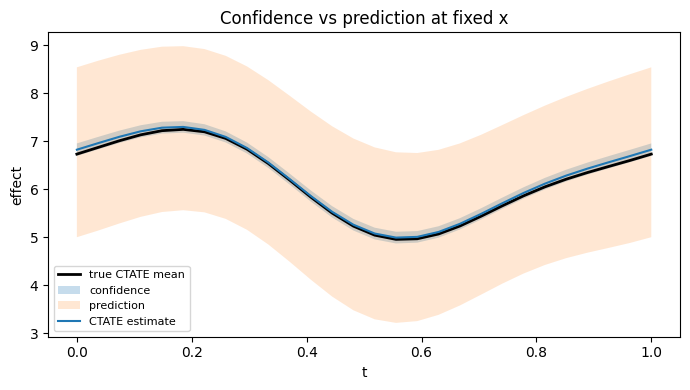

In [5]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(sim.tseq, truth, color="black", lw=2, label="true CTATE mean")
ax.fill_between(sim.tseq, conf.lower, conf.upper, alpha=0.25, label="confidence")
ax.fill_between(sim.tseq, pred.lower, pred.upper, alpha=0.18, label="prediction")
ax.plot(sim.tseq, conf.center, lw=1.5, label="CTATE estimate")
ax.set(xlabel="t", ylabel="effect", title="Confidence vs prediction at fixed x")
ax.legend(loc="best", fontsize=8)
fig.tight_layout()